In [19]:
from DFTStructureGenerator.descriptor import (
    DUPLICATE_CL_IDS,
    DUPLICATE_N_IDS,
    build_descriptor_maps,
    dataframe_to_descriptors,
    load_descriptor_maps,
    save_descriptor_maps,
)
import numpy as np
from tqdm import tqdm
import pandas as pd
from rdkit import Chem
from ase.db import connect
from DFTStructureGenerator.Build_DataBase import (
    B_TYPE_ORDER,
    CL_SUBSTRATE_TYPE_ORDER,
    LB_TYPE_ORDER,
    get_boron_type,
    get_cl_substrate_type,
    get_lb_type,
)
from DFTStructureGenerator.project_paths import CSV_DIR, DESCRIPTOR_DIR, FIGURE_DIR, TS_DATA_DIR, repo_path


In [13]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold
import pickle
np.random.seed(0)

In [15]:
from matplotlib import pyplot as plt
from DFTStructureGenerator.draw import (
    draw_correlation_map,
    plot_scatter_with_metrics,
)


In [16]:
duplicate_N_id = DUPLICATE_N_IDS
duplicate_Cl_id = DUPLICATE_CL_IDS


In [17]:
DB_PATH = repo_path("boron_ccl.db")
BN_CSV_PATH = CSV_DIR / "reactants_B_N.csv"
CL_CSV_PATH = CSV_DIR / "reactants_Cl.csv"
BN_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "BNdes_new2.pkl"
CL_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "Cldes_new2.pkl"

# Descriptor Generation

In [ ]:
B_N_des_map, Cl_des_map = build_descriptor_maps(
    db_path=DB_PATH,
    bn_csv_path=BN_CSV_PATH,
    cl_csv_path=CL_CSV_PATH,
    duplicate_cl_ids=duplicate_Cl_id,
)


In [ ]:
save_descriptor_maps(
    B_N_des_map,
    Cl_des_map,
    bn_path=BN_DESCRIPTOR_PATH,
    cl_path=CL_DESCRIPTOR_PATH,
)


# Feature Loading

In [8]:
B_N_des_map, Cl_des_map = load_descriptor_maps(
    bn_path=BN_DESCRIPTOR_PATH,
    cl_path=CL_DESCRIPTOR_PATH,
)


# Training model

In [9]:
# Combined quantitative features
data_csv = pd.read_csv(TS_DATA_DIR / "Borane_all.csv")
y = data_csv["deltaGa(kcal/mol)"]
target_eng = data_csv["deltaGa(kcal/mol)"]
all_Xs = dataframe_to_descriptors(
    data_csv,
    B_N_des_map,
    Cl_des_map,
    duplicate_cl_ids=duplicate_Cl_id,
)


100%|██████████| 9237/9237 [00:00<00:00, 52028.18it/s]


In [10]:
np.array(all_Xs).shape

(9237, 18)

# Descriptor Correlation

Max correlation:  0.8949314973189016


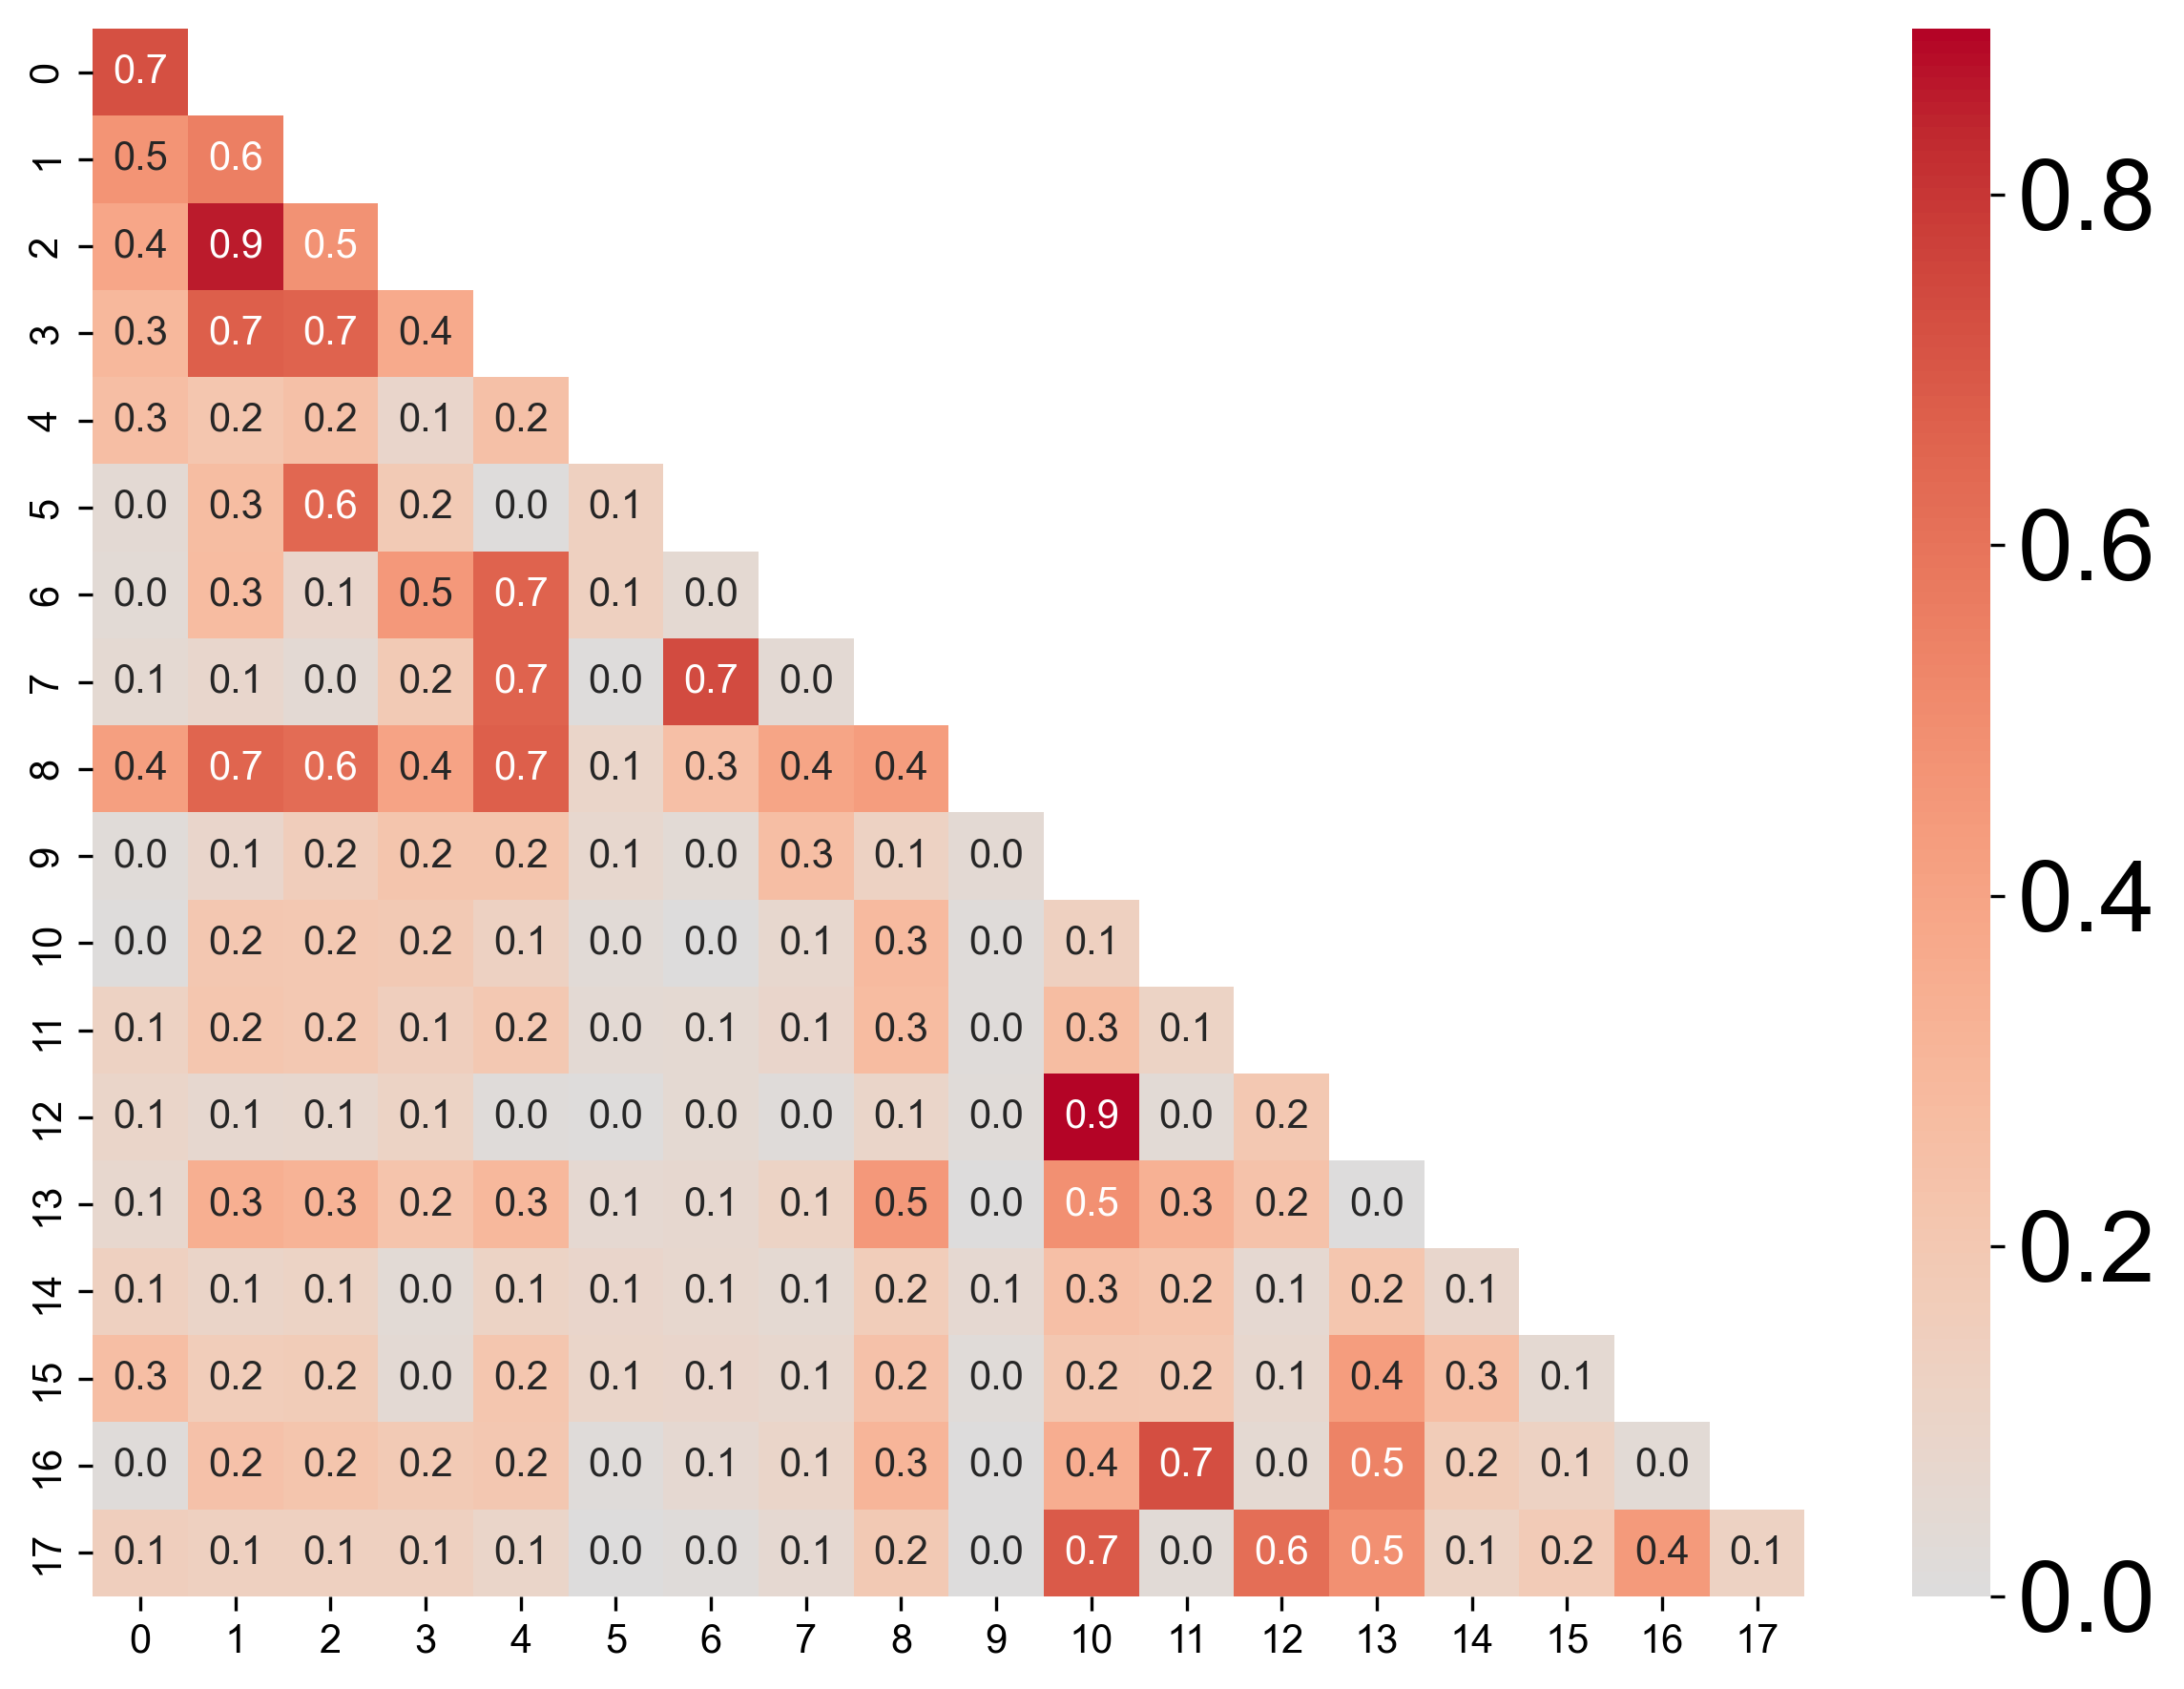

In [11]:
correlation_matrix = draw_correlation_map(all_Xs, figure_size=(8, 6), colors='coolwarm', annot=True, show_label=True, target = y.to_numpy())

# 5-Fold Validation

In [12]:
all_X = np.array(all_Xs)
y = data_csv['deltaGa(kcal/mol)'].to_numpy()
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s = []
all_pred = [0 for _ in range(len(all_X))]
for train_ids, test_ids in list(kf.split(all_X)):
    model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
    # model = RandomForestRegressor()
    model.fit(all_X[train_ids], y[train_ids])
    y_pred = model.predict(all_X[test_ids])
    print(f"R2: {r2_score(y[test_ids], y_pred):.3f}, MAE: {mean_absolute_error(y[test_ids], y_pred):.3f}, MSE: {mean_squared_error(y[test_ids], y_pred):.3f}")
    all_r2s.append(r2_score(y[test_ids], y_pred))
    for test_id, y_p in zip(test_ids, y_pred):
        all_pred[test_id] = y_p
print(f"Mean of 5-Fold R2: {np.mean(all_r2s):.3f}")

R2: 0.892, MAE: 1.415, MSE: 4.311
R2: 0.903, MAE: 1.430, MSE: 3.948
R2: 0.904, MAE: 1.404, MSE: 3.740
R2: 0.914, MAE: 1.338, MSE: 3.439
R2: 0.917, MAE: 1.370, MSE: 3.467
Mean of 5-Fold R2: 0.906


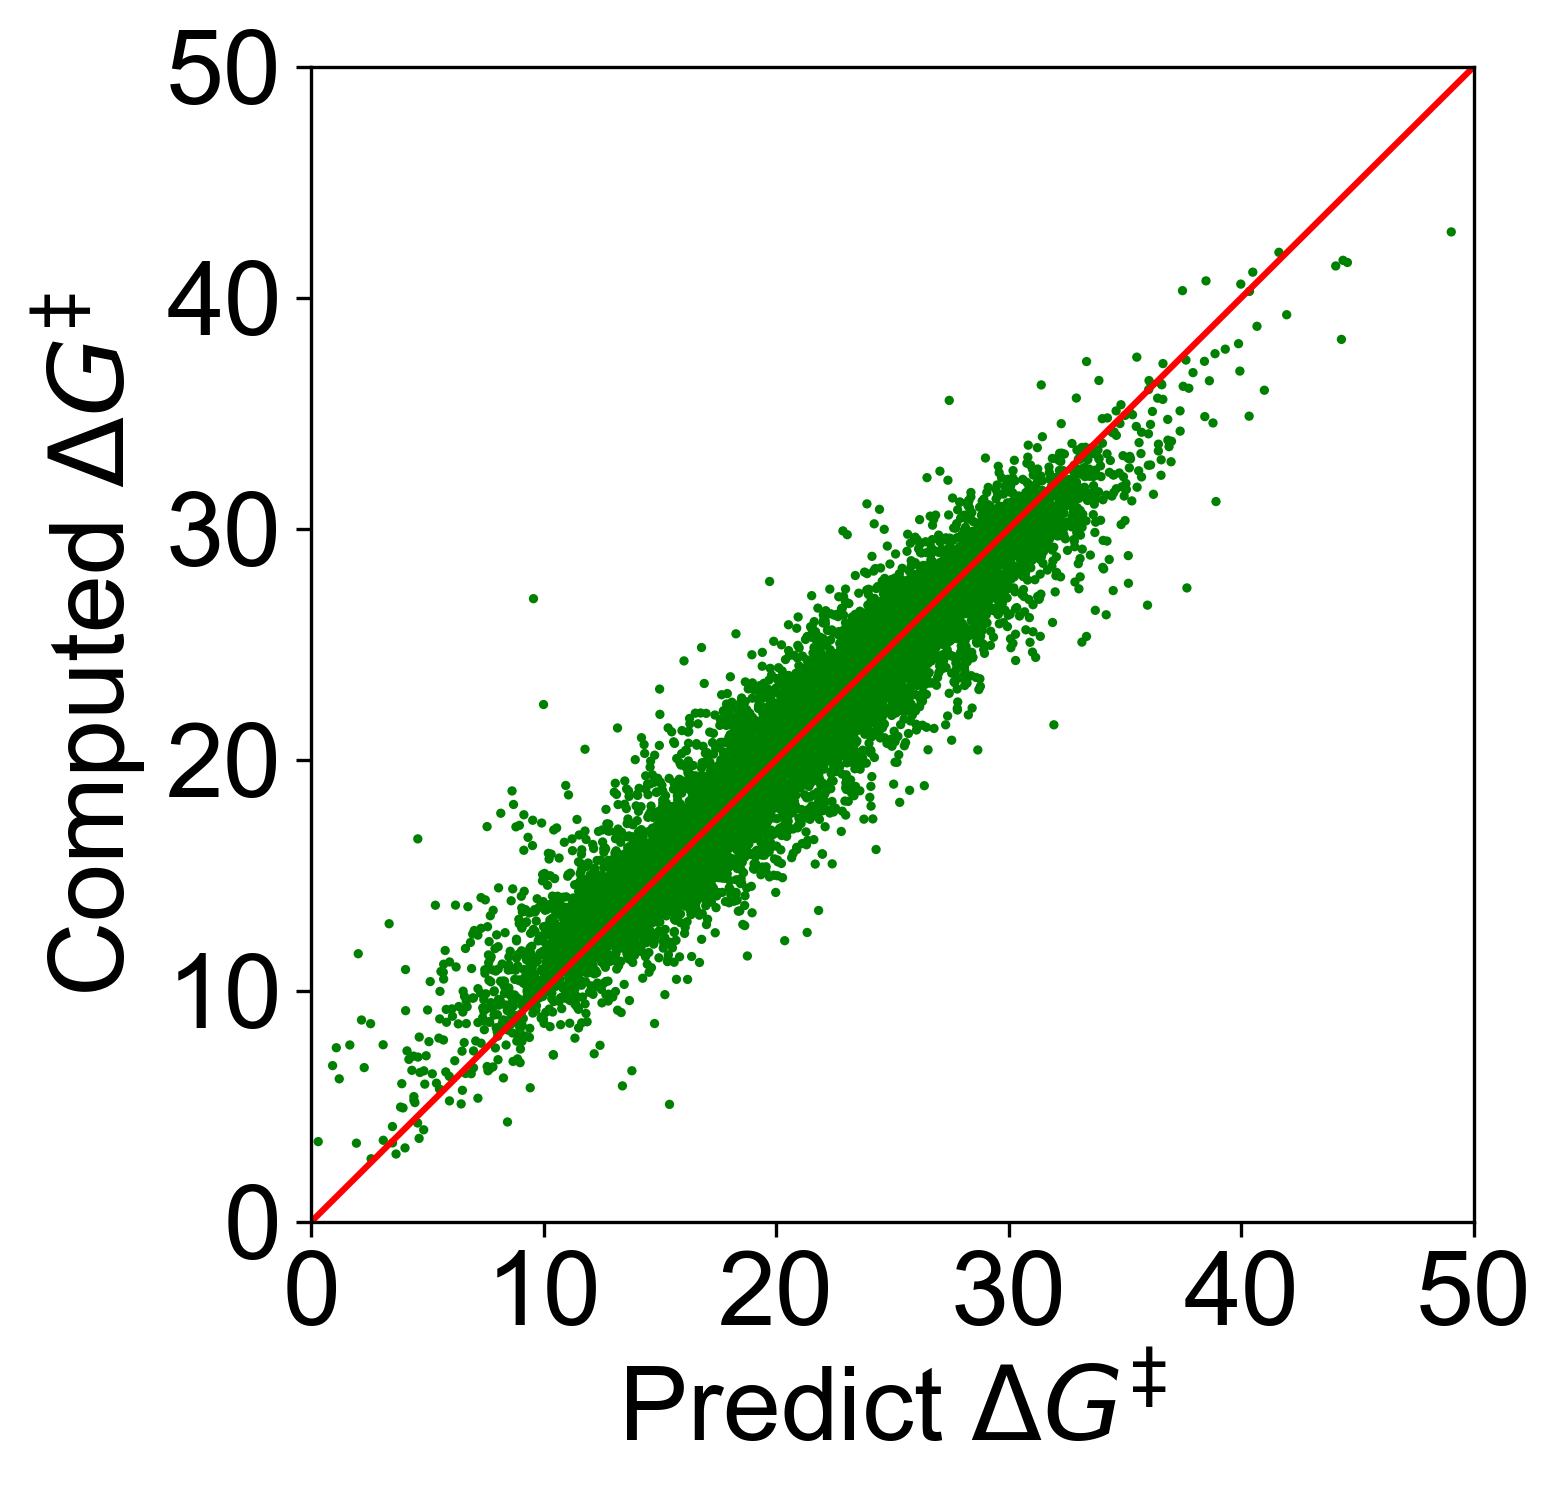

In [12]:
plot_scatter_with_metrics(y, all_pred, min_=0, max_=50)


In [13]:
model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
model.fit(all_Xs, y)
FI = model.feature_importances_

In [14]:
des_name_std_sorted = [
    '$\\Delta G_{\\mathrm{rxn}}$',                 # deltaG
    'LB-B· $P^{\\mathrm{spin}}$',                  # B_N B_spin
    'LB-B· $q^{\\mathrm{B}}_{\\mathrm{H}}$',       # B_N B_Hirshfield_charge
    'LB-B· $d_{\\mathrm{LB-B}}$',                  # B_N B_N_dist
    'LB-B· $E_{\\mathrm{SOMO}}$',                  # B_N Alpha-HOMO
    'LB-B-Cl $q^{\\mathrm{B}}_{\\mathrm{H}}$',     # B_N_Cl B_Hirshfield_charge
    'LB-B-Cl $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',    # B_N_Cl Cl_Hirshfield_charge
    'LB-B· $d_{\\mathrm{B-Cl}}$',                  # B_N_Cl N_Cl_dist
    'LB-B-Cl $E_{\\mathrm{LUMO}}$',                # B_N_Cl LUMO
    'LB-B-Cl $\\%V_{\\mathrm{bur}}$',              # B_N_Cl Bv6radius
    'Cl-C $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',       # C_Cl Cl_Hirshfield_charge
    'Cl-C $q^{\\mathrm{C}}_{\\mathrm{H}}$',        # C_Cl C_Hirshfield_charge
    'Cl-C $d_{\\mathrm{Cl-C}}$',                   # C_Cl C_Cl_dist
    'Cl-C $E_{\\mathrm{LUMO}}$',                   # C_Cl LUMO
    'C_Cl $\\%V_{\\mathrm{bur}}$',                 # C_Cl Bv6radius
    'C· $P^{\\mathrm{spin}}$',                     # C C_spin
    'C· $q^{\\mathrm{C}}_{\\mathrm{H}}$',          # C C_Hirshfield_charge
    'C· $E_{\\mathrm{SOMO}}$'                      # C Alpha-HOMO
]

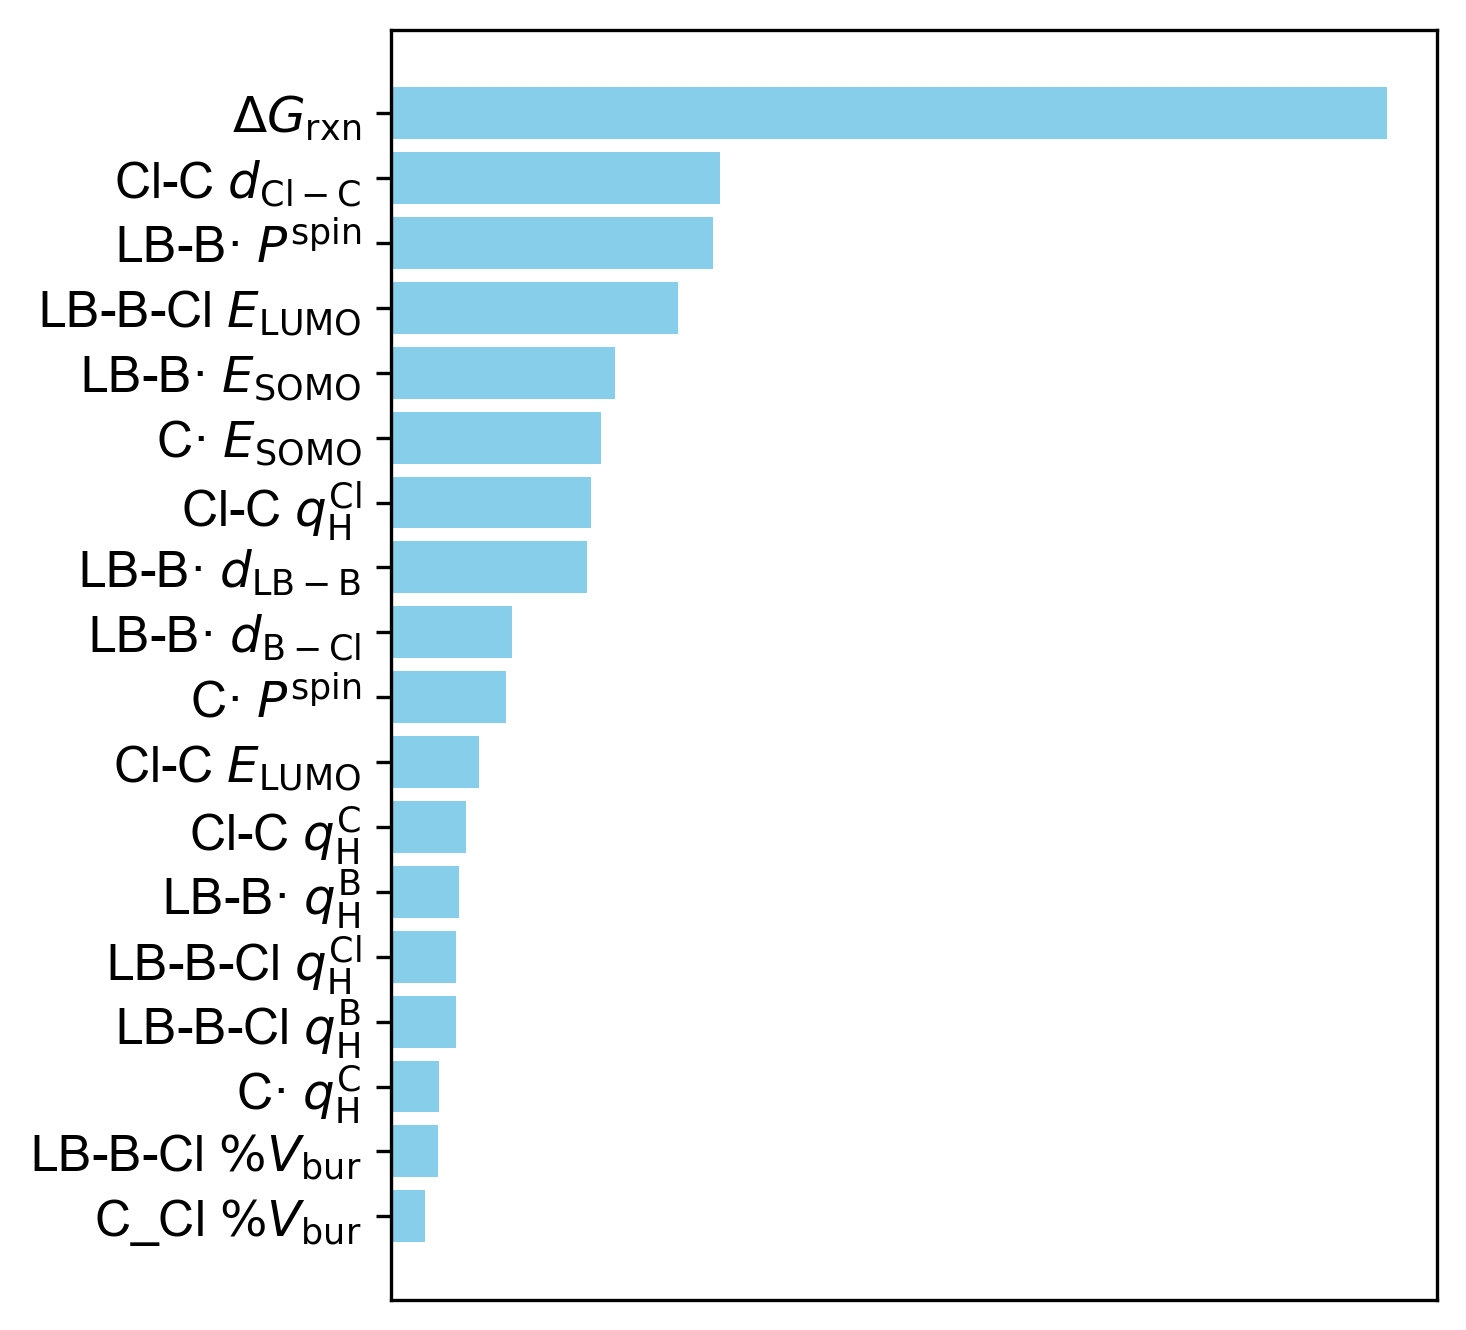

In [15]:
plt.figure(figsize=(4.5,5.5), dpi=300)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.barh(np.array(des_name_std_sorted)[np.argsort(FI)], np.sort(FI), color='skyblue')
# plt.xlabel('Feature Importance')
plt.xticks([])
plt.yticks(fontsize=12)
# plt.ylabel('Features')
# plt.title('Feature Importances')
plt.savefig(FIGURE_DIR / "Figure_model_feature_importance.png", dpi=300, bbox_inches='tight')

# Other Seeds

In [27]:
all_X = np.array(all_Xs)
y = data_csv['deltaGa(kcal/mol)'].to_numpy()
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for seed in range(10):
    all_r2s, all_mae, all_mse = [], [], []
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    for train_ids, test_ids in list(kf.split(all_X)):
        model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
        # model = RandomForestRegressor()
        model.fit(all_X[train_ids], y[train_ids])
        y_pred = model.predict(all_X[test_ids])
        all_r2s.append(r2_score(y[test_ids], y_pred))
        all_mae.append(mean_absolute_error(y[test_ids], y_pred))
        all_mse.append(mean_squared_error(y[test_ids], y_pred))
    print(f"Seed: {seed}, R2: {np.mean(all_r2s):.3f}, MAE: {np.mean(all_mae):.3f}, MSE: {np.mean(all_mse):.3f}")

Seed: 0, R2: 0.909, MAE: 1.389, MSE: 3.662
Seed: 1, R2: 0.907, MAE: 1.394, MSE: 3.716
Seed: 2, R2: 0.906, MAE: 1.390, MSE: 3.789
Seed: 3, R2: 0.907, MAE: 1.386, MSE: 3.733
Seed: 4, R2: 0.908, MAE: 1.386, MSE: 3.674
Seed: 5, R2: 0.908, MAE: 1.390, MSE: 3.673
Seed: 6, R2: 0.907, MAE: 1.402, MSE: 3.742
Seed: 7, R2: 0.907, MAE: 1.393, MSE: 3.715
Seed: 8, R2: 0.910, MAE: 1.377, MSE: 3.613
Seed: 9, R2: 0.908, MAE: 1.392, MSE: 3.689


# OOD

## OOD around Indexs

OOD by Cl_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Cl_Index,1,142,36,7237,2000,0.693829,2.394164,14.513473
1,Cl_Index,2,142,36,7497,1740,0.895497,1.497331,4.003722
2,Cl_Index,3,142,36,7568,1669,0.890117,1.437707,3.785129
3,Cl_Index,4,143,35,7410,1827,0.760429,2.185218,9.025851
4,Cl_Index,5,143,35,7236,2001,0.792468,2.043443,8.362480


Mean fold R2: 0.8064680409470736 MAE: 1.9115726980955805
Overall R2: 0.7969097730616534 MAE: 1.93510236027012


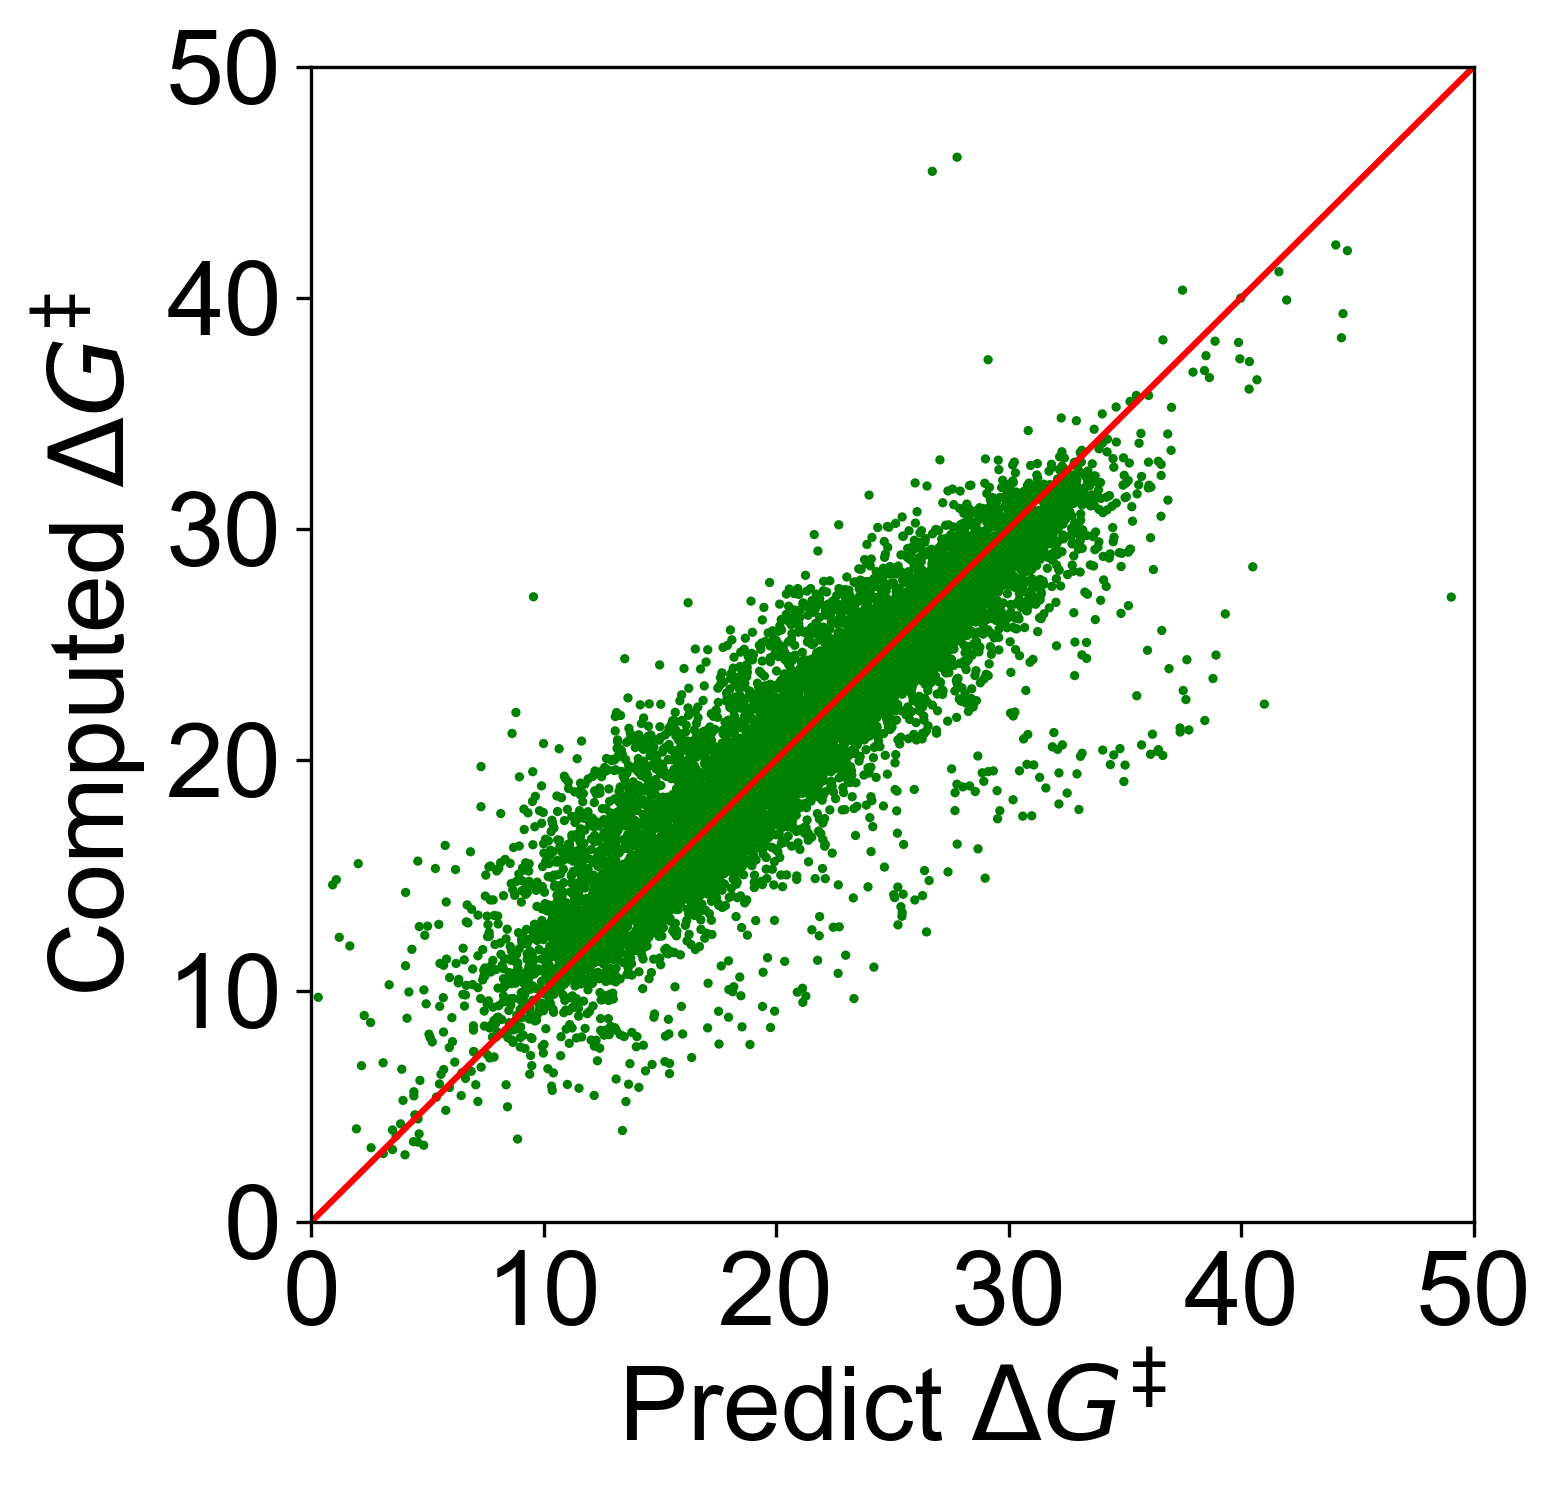

OOD by B_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,B_Index,1,44,11,7868,1369,0.852026,1.919076,6.352181
1,B_Index,2,44,11,7752,1485,0.864832,1.685644,5.344557
2,B_Index,3,44,11,7149,2088,0.861677,1.687065,5.214500
3,B_Index,4,44,11,7422,1815,0.858649,1.657275,5.051280
4,B_Index,5,44,11,6757,2480,0.884466,1.536417,4.822243


Mean fold R2: 0.8643299295654584 MAE: 1.6970954336078656
Overall R2: 0.8691997040718249 MAE: 1.674922200539898


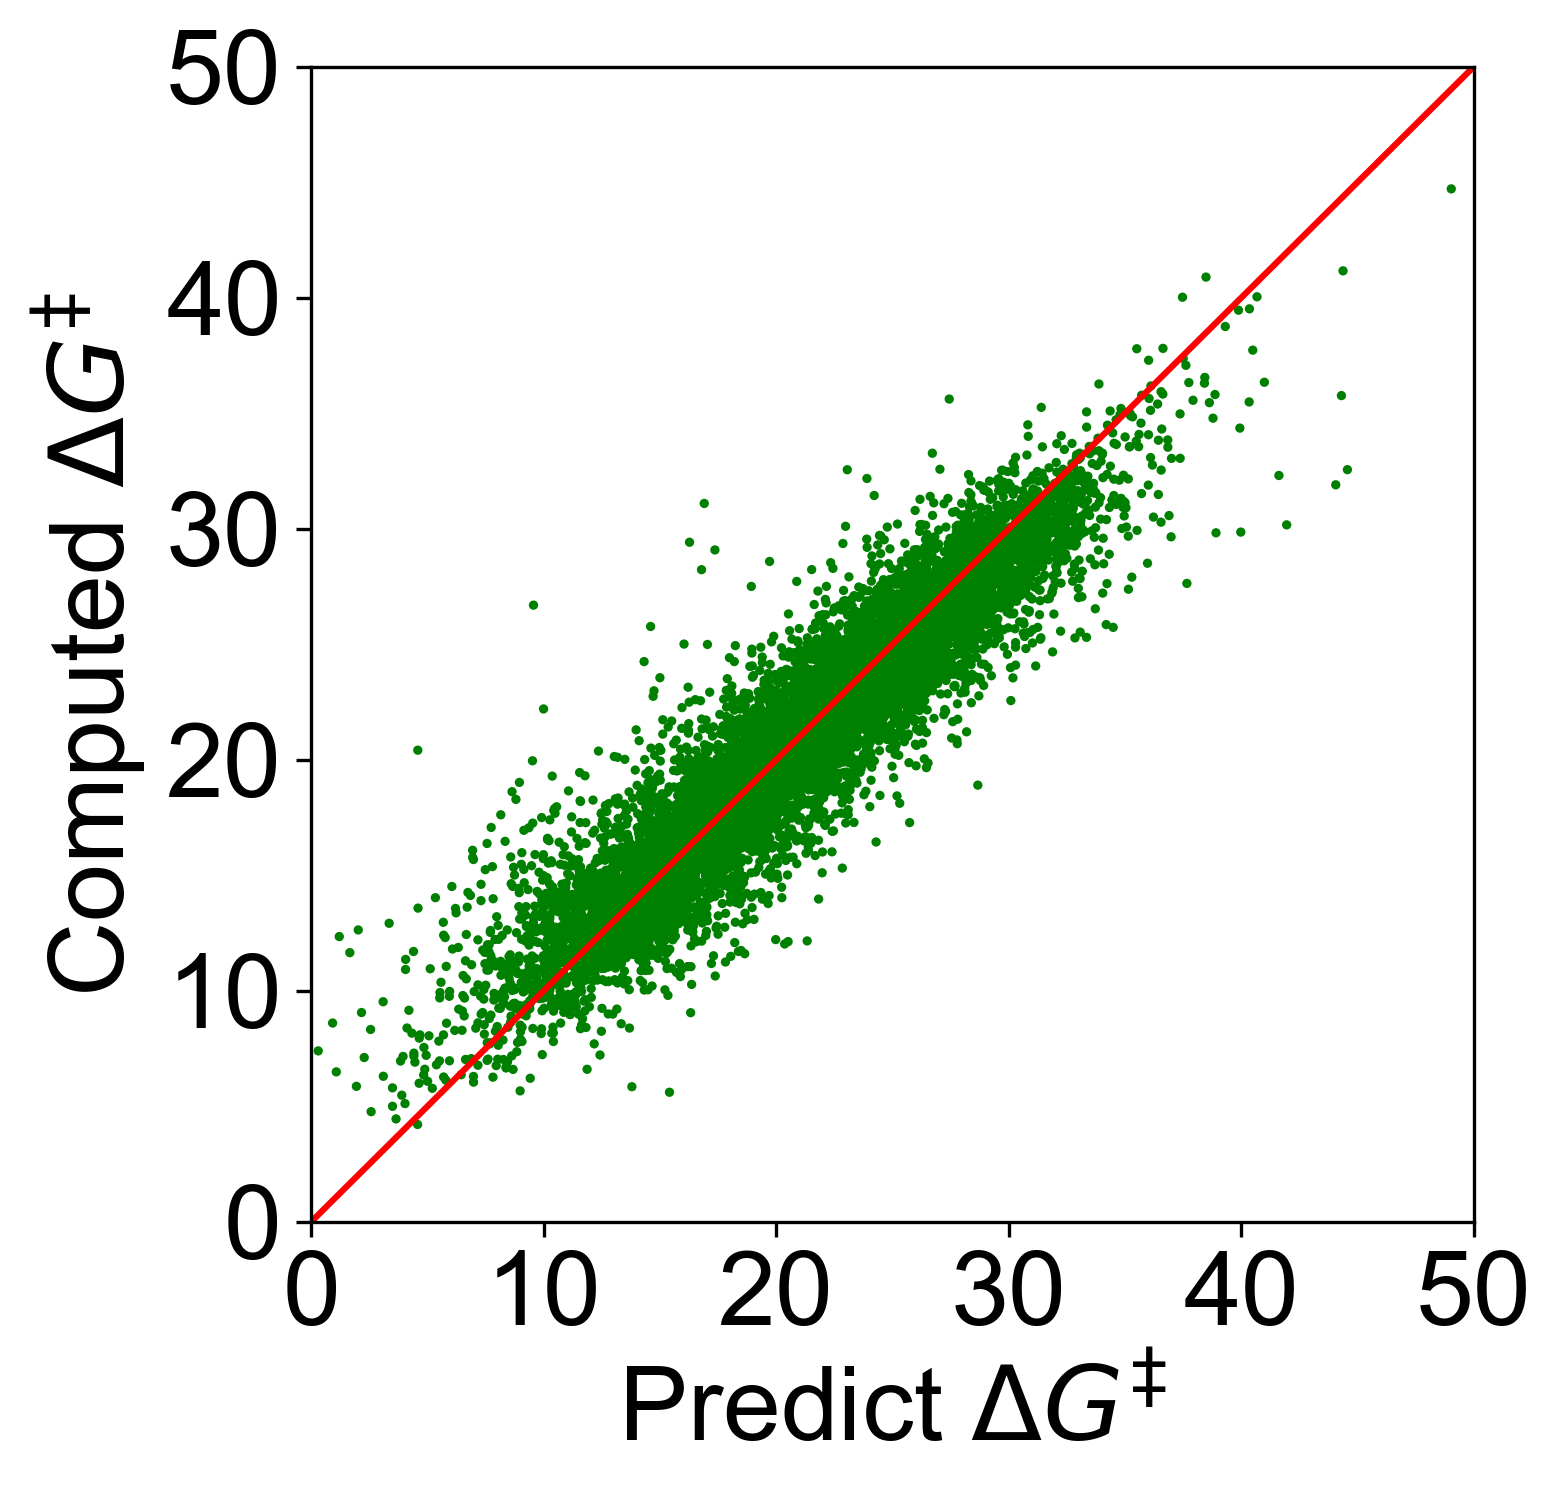

OOD by Nu_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Nu_Index,1,307,77,6783,2454,0.837162,1.712112,6.479585
1,Nu_Index,2,307,77,7501,1736,0.894447,1.523000,4.229997
2,Nu_Index,3,307,77,7673,1564,0.853561,1.595034,5.773963
3,Nu_Index,4,307,77,7516,1721,0.886258,1.651066,5.114178
4,Nu_Index,5,308,76,7475,1762,0.841606,1.673574,5.677906


Mean fold R2: 0.8626069329008461 MAE: 1.6309572460050852
Overall R2: 0.862658841125141 MAE: 1.638021718748413


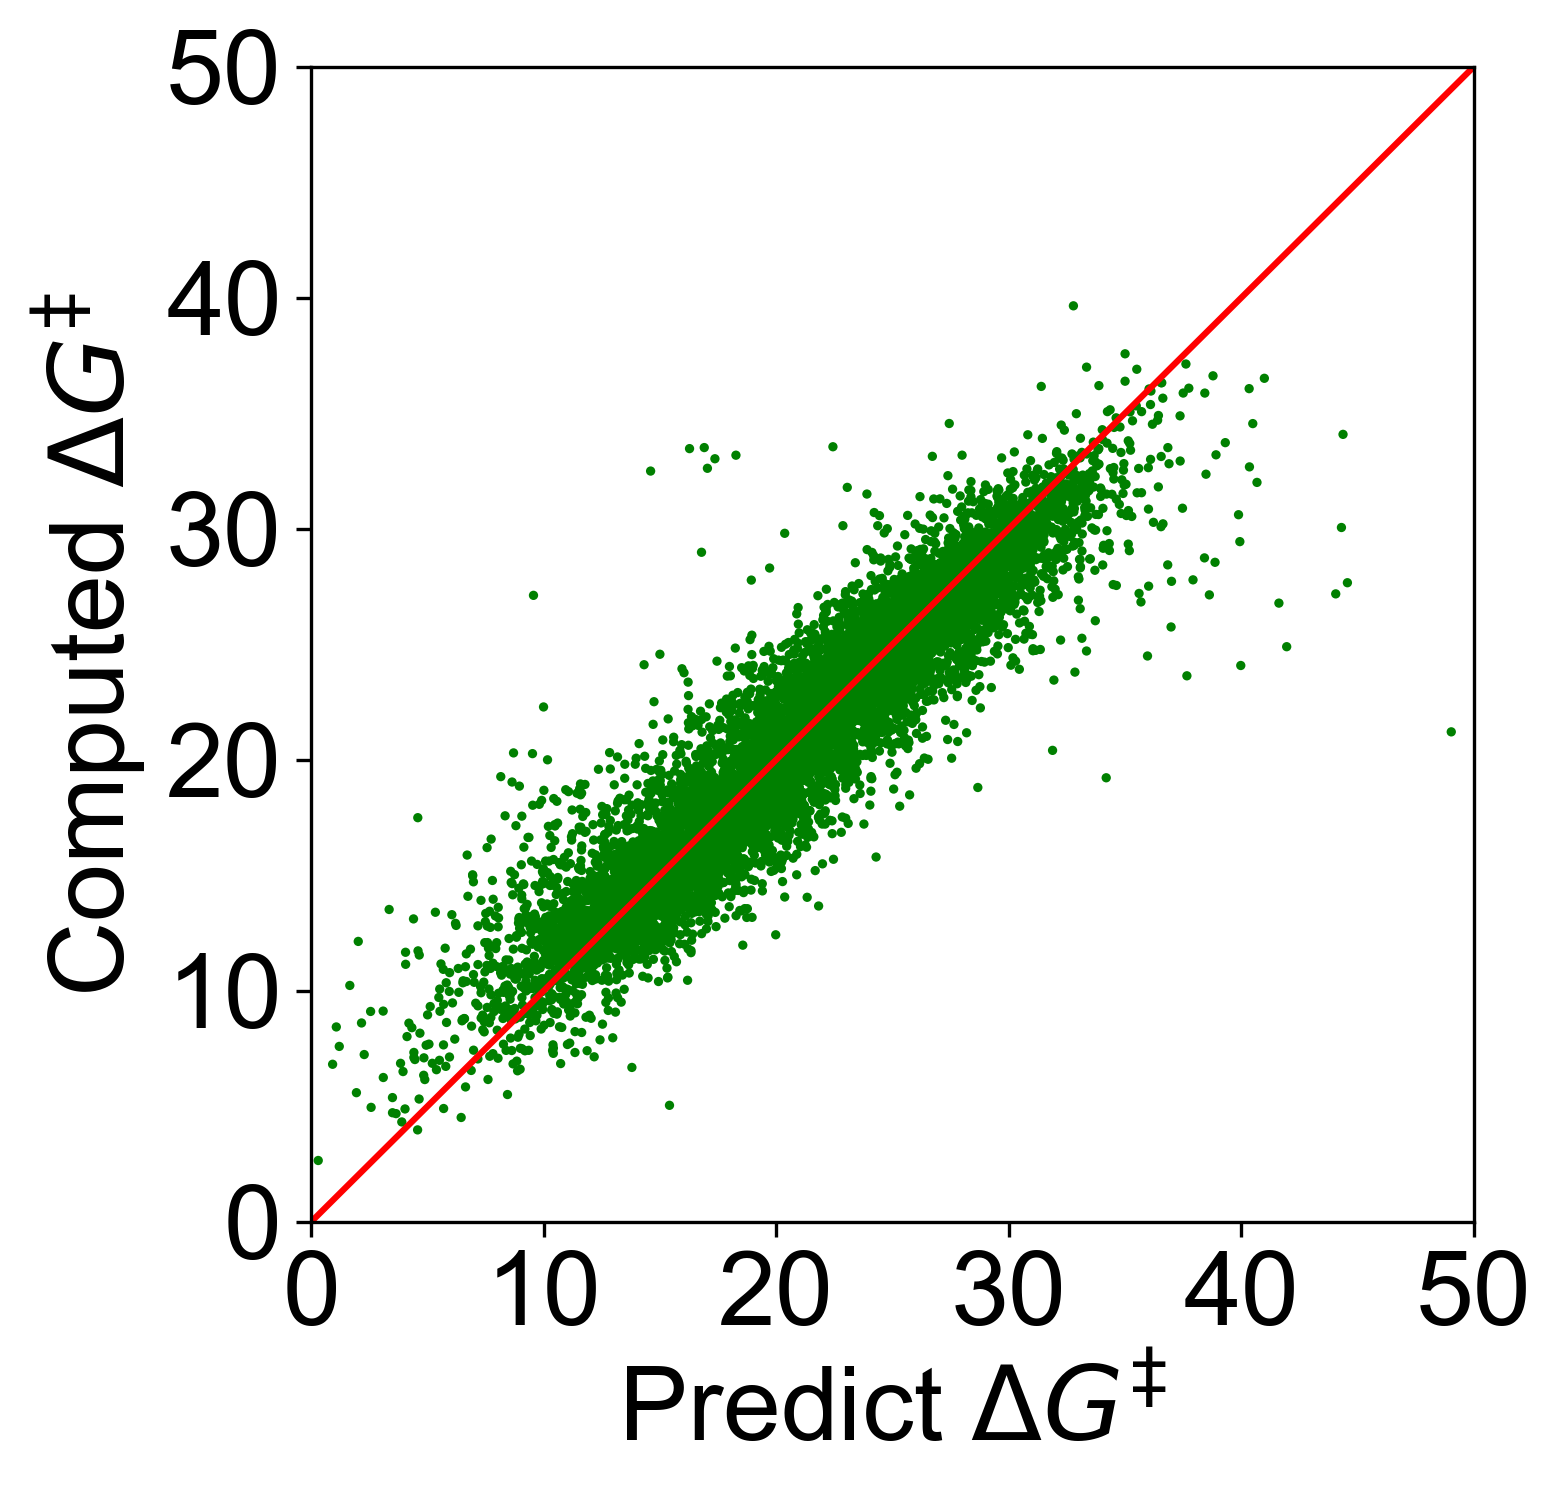

,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Cl_Index,1,142,36,7237,2000,0.693829,2.394164,14.513473
1,Cl_Index,2,142,36,7497,1740,0.895497,1.497331,4.003722
2,Cl_Index,3,142,36,7568,1669,0.890117,1.437707,3.785129
3,Cl_Index,4,143,35,7410,1827,0.760429,2.185218,9.025851
4,Cl_Index,5,143,35,7236,2001,0.792468,2.043443,8.362480
5,B_Index,1,44,11,7868,1369,0.852026,1.919076,6.352181
6,B_Index,2,44,11,7752,1485,0.864832,1.685644,5.344557
7,B_Index,3,44,11,7149,2088,0.861677,1.687065,5.214500
8,B_Index,4,44,11,7422,1815,0.858649,1.657275,5.051280
9,B_Index,5,44,11,6757,2480,0.884466,1.536417,4.822243


In [21]:
def run_index_ood(
    data_df,
    index_column,
    label=None,
    n_splits=5,
    target_column="deltaGa(kcal/mol)",
    min_test_size=2,
):
    label = label or index_column
    index_values = np.sort(data_df[index_column].dropna().unique())
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)

    result_rows = []
    pred_rows = []
    for fold_id, (train_ids, test_ids) in enumerate(kf.split(index_values), start=1):
        train_values = index_values[train_ids]
        test_values = index_values[test_ids]
        train_df = data_df.loc[data_df[index_column].isin(train_values)].reset_index(drop=True)
        test_df = data_df.loc[data_df[index_column].isin(test_values)].reset_index(drop=True)
        if len(test_df) < min_test_size or len(train_df) == 0:
            continue

        train_X = dataframe_to_descriptors(
            train_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        test_X = dataframe_to_descriptors(
            test_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        train_y = train_df[target_column]
        test_y = test_df[target_column]

        model = CatBoostRegressor(
            iterations=10000,
            learning_rate=0.01,
            depth=6,
            verbose=0,
            random_state=0,
        )
        model.fit(train_X, train_y)
        y_pred = model.predict(test_X)

        result_rows.append({
            "OOD_axis": label,
            "fold": fold_id,
            "train_index_count": len(train_values),
            "test_index_count": len(test_values),
            "train_size": len(train_df),
            "test_size": len(test_df),
            "R2": r2_score(test_y, y_pred),
            "MAE": mean_absolute_error(test_y, y_pred),
            "MSE": mean_squared_error(test_y, y_pred),
        })
        pred_rows.extend(
            {
                "OOD_axis": label,
                "fold": fold_id,
                "y_true": y_true,
                "y_pred": pred,
            }
            for y_true, pred in zip(test_y.to_numpy(), y_pred)
        )

    return pd.DataFrame(result_rows), pd.DataFrame(pred_rows)


ood_index_configs = {
    "Cl_Index": "Cl_Index",
    "B_Index": "B_Index",
    "N_Index": "Nu_Index",
}
ood_index_results = {}
ood_index_predictions = {}

for index_column, label in ood_index_configs.items():
    result_df, pred_df = run_index_ood(data_csv, index_column=index_column, label=label)
    ood_index_results[label] = result_df
    ood_index_predictions[label] = pred_df

    print(f"OOD by {label}")
    display(result_df)
    if pred_df.empty:
        print(f"No valid OOD folds for {label}")
        continue
    print(
        "Mean fold R2:",
        result_df["R2"].mean(),
        "MAE:",
        result_df["MAE"].mean(),
    )
    print(
        "Overall R2:",
        r2_score(pred_df["y_true"], pred_df["y_pred"]),
        "MAE:",
        mean_absolute_error(pred_df["y_true"], pred_df["y_pred"]),
    )
    plot_scatter_with_metrics(
        pred_df["y_true"].to_numpy(),
        pred_df["y_pred"].to_numpy(),
        min_=0,
        max_=50,
    )


nonempty_ood_index_results = [
    result_df for result_df in ood_index_results.values() if not result_df.empty
]
if nonempty_ood_index_results:
    ood_index_summary = pd.concat(nonempty_ood_index_results, ignore_index=True)
else:
    ood_index_summary = pd.DataFrame()
display(ood_index_summary)


## OOD around Types

B_type counts:
B_type
R2BH    2500
RBH2    5934
BH3      803

Nu_type counts:
Nu_type
Amine/Aryl N    5897
Phosphine       1833
NHC             1507

Cl_type counts:
Cl_type
CCl4     212
CCl3    1793
CCl2    2107
CCl     5125

OOD by B_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,B_type,R2BH,6737,2500,0.808557,2.041933,8.119509
1,B_type,RBH2,3303,5934,0.854490,1.755245,5.614904
2,B_type,BH3,8434,803,0.936600,1.120740,2.367567


Overall R2: 0.850725943433732 MAE: 1.7776780754511132


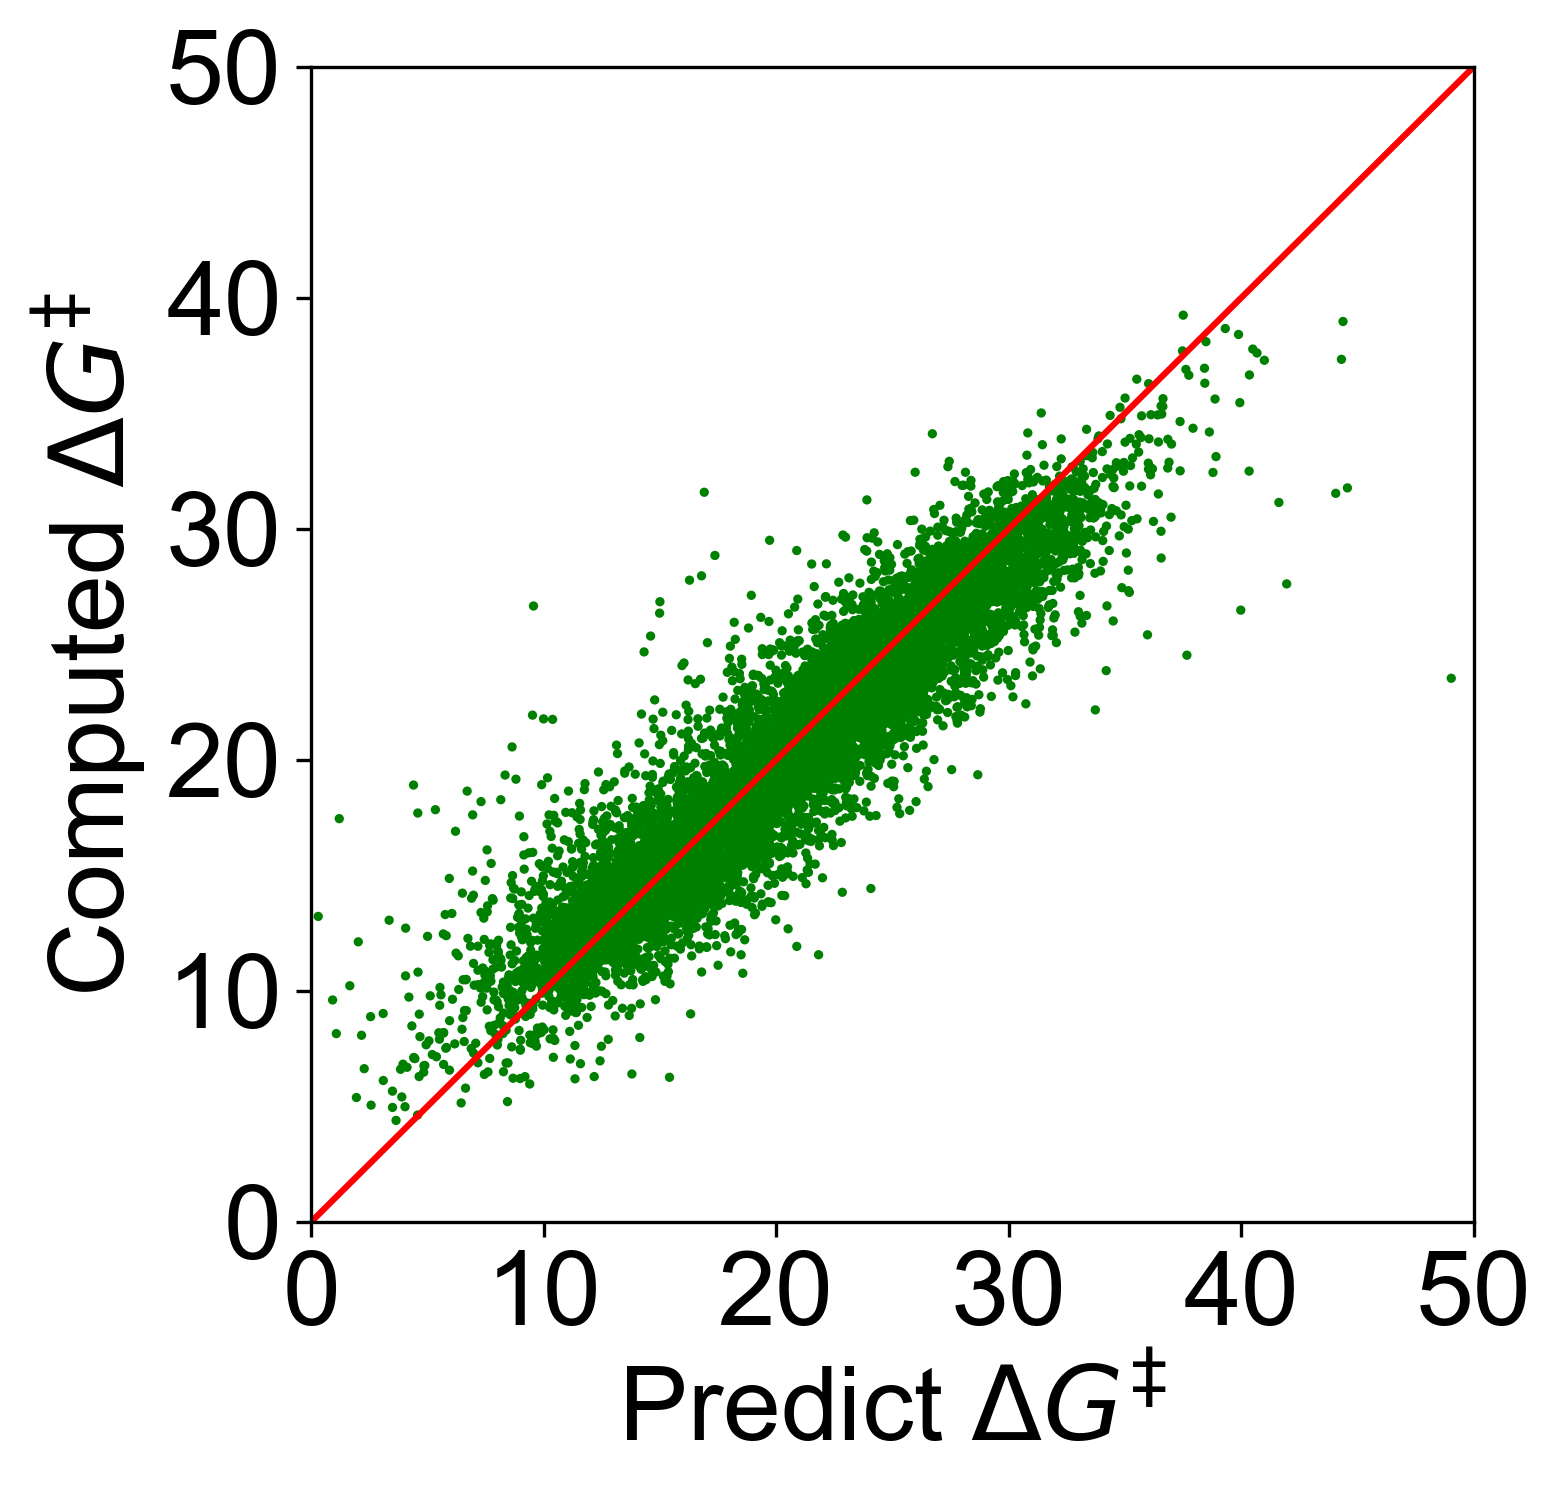

OOD by Nu_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,Nu_type,Amine/Aryl N,3340,5897,0.755915,2.410668,10.410664
1,Nu_type,Phosphine,7404,1833,0.503666,2.385533,12.782575
2,Nu_type,NHC,7730,1507,0.750277,2.020231,7.422034


Overall R2: 0.7418642862736917 MAE: 2.3419812718523922


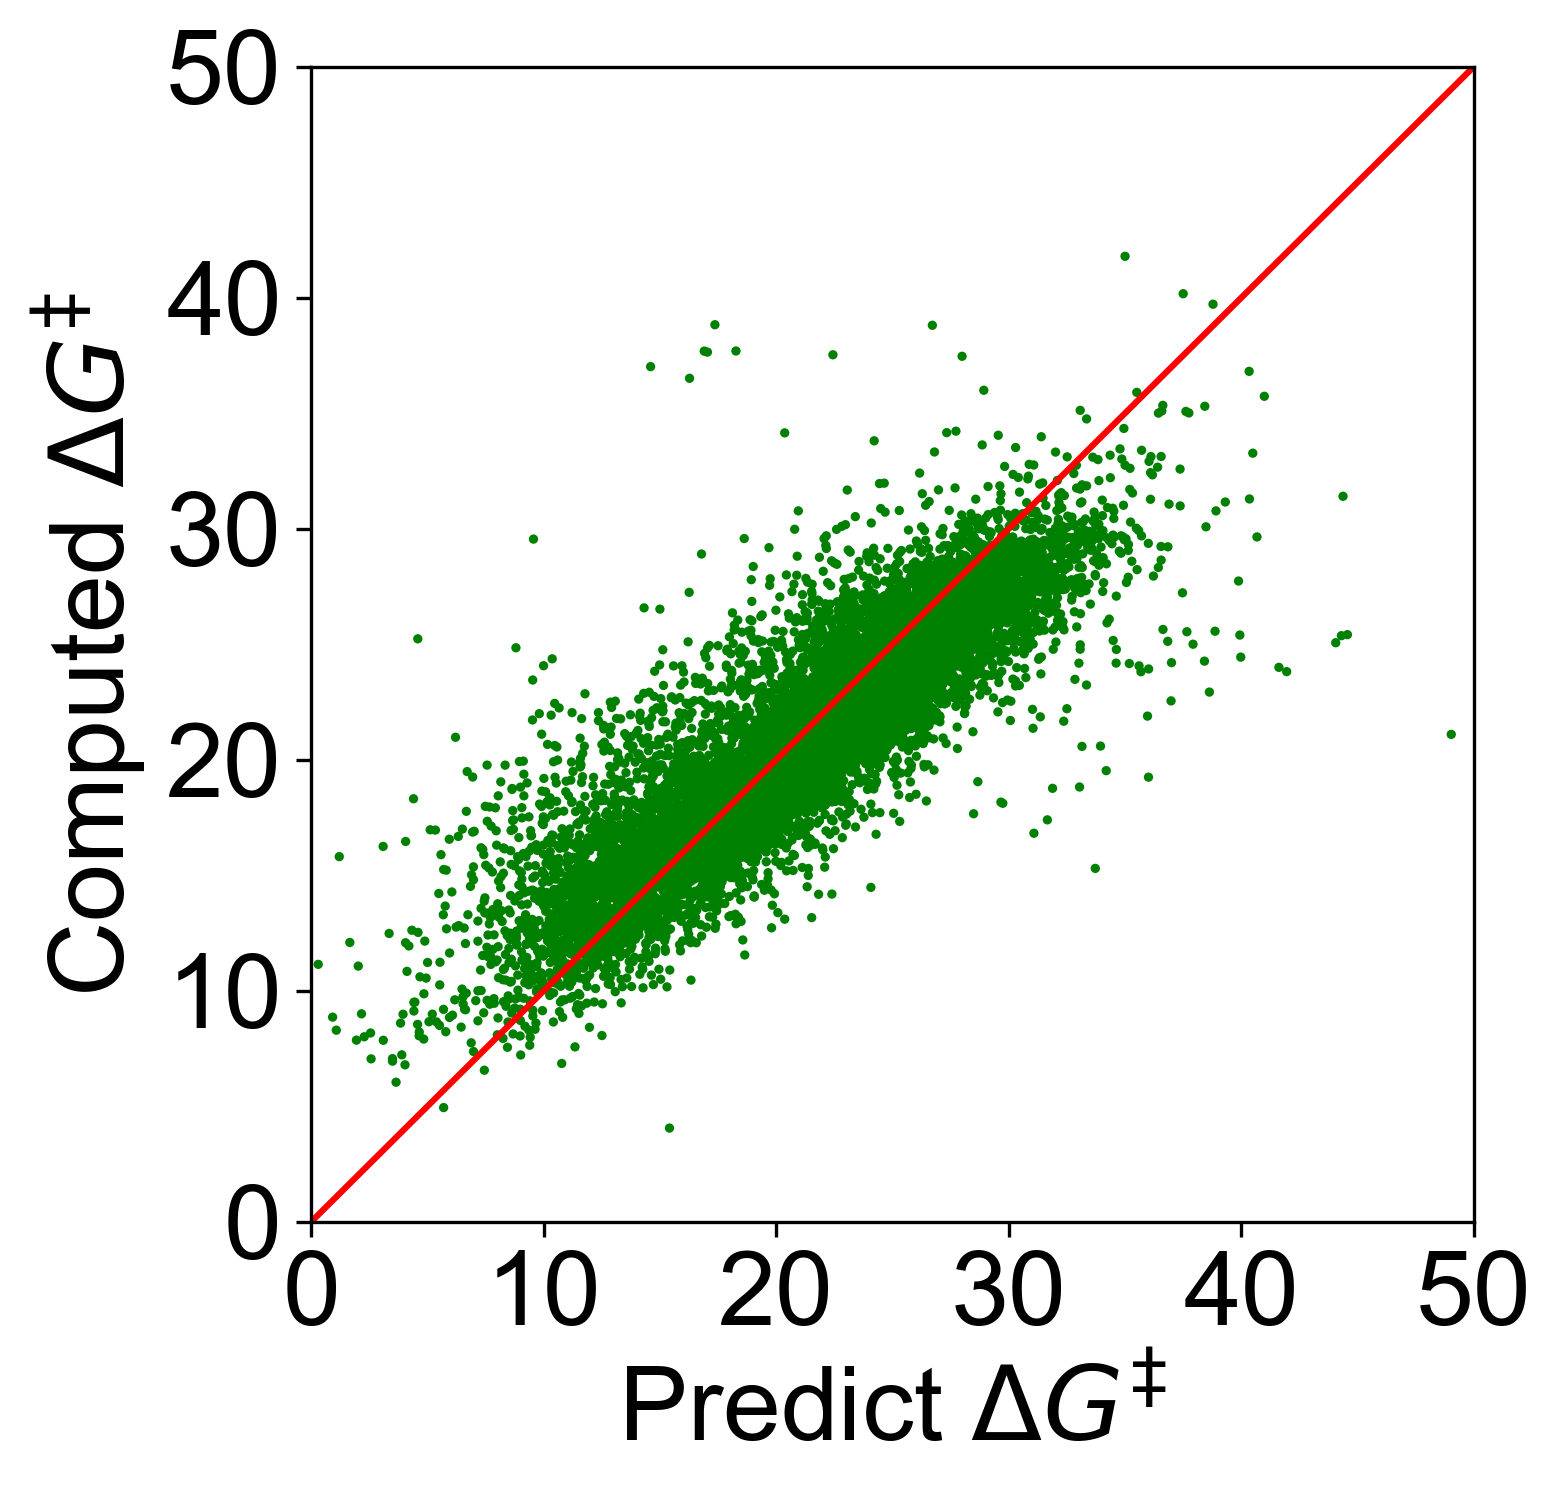

OOD by Cl_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,Cl_type,CCl4,9025,212,0.894737,1.378639,2.843366
1,Cl_type,CCl3,7444,1793,0.903820,1.412401,3.526066
2,Cl_type,CCl2,7130,2107,0.894317,1.485385,4.010414
3,Cl_type,CCl,4112,5125,0.576747,3.267642,18.148714


Overall R2: 0.7085780652441118 MAE: 2.4576242720260657


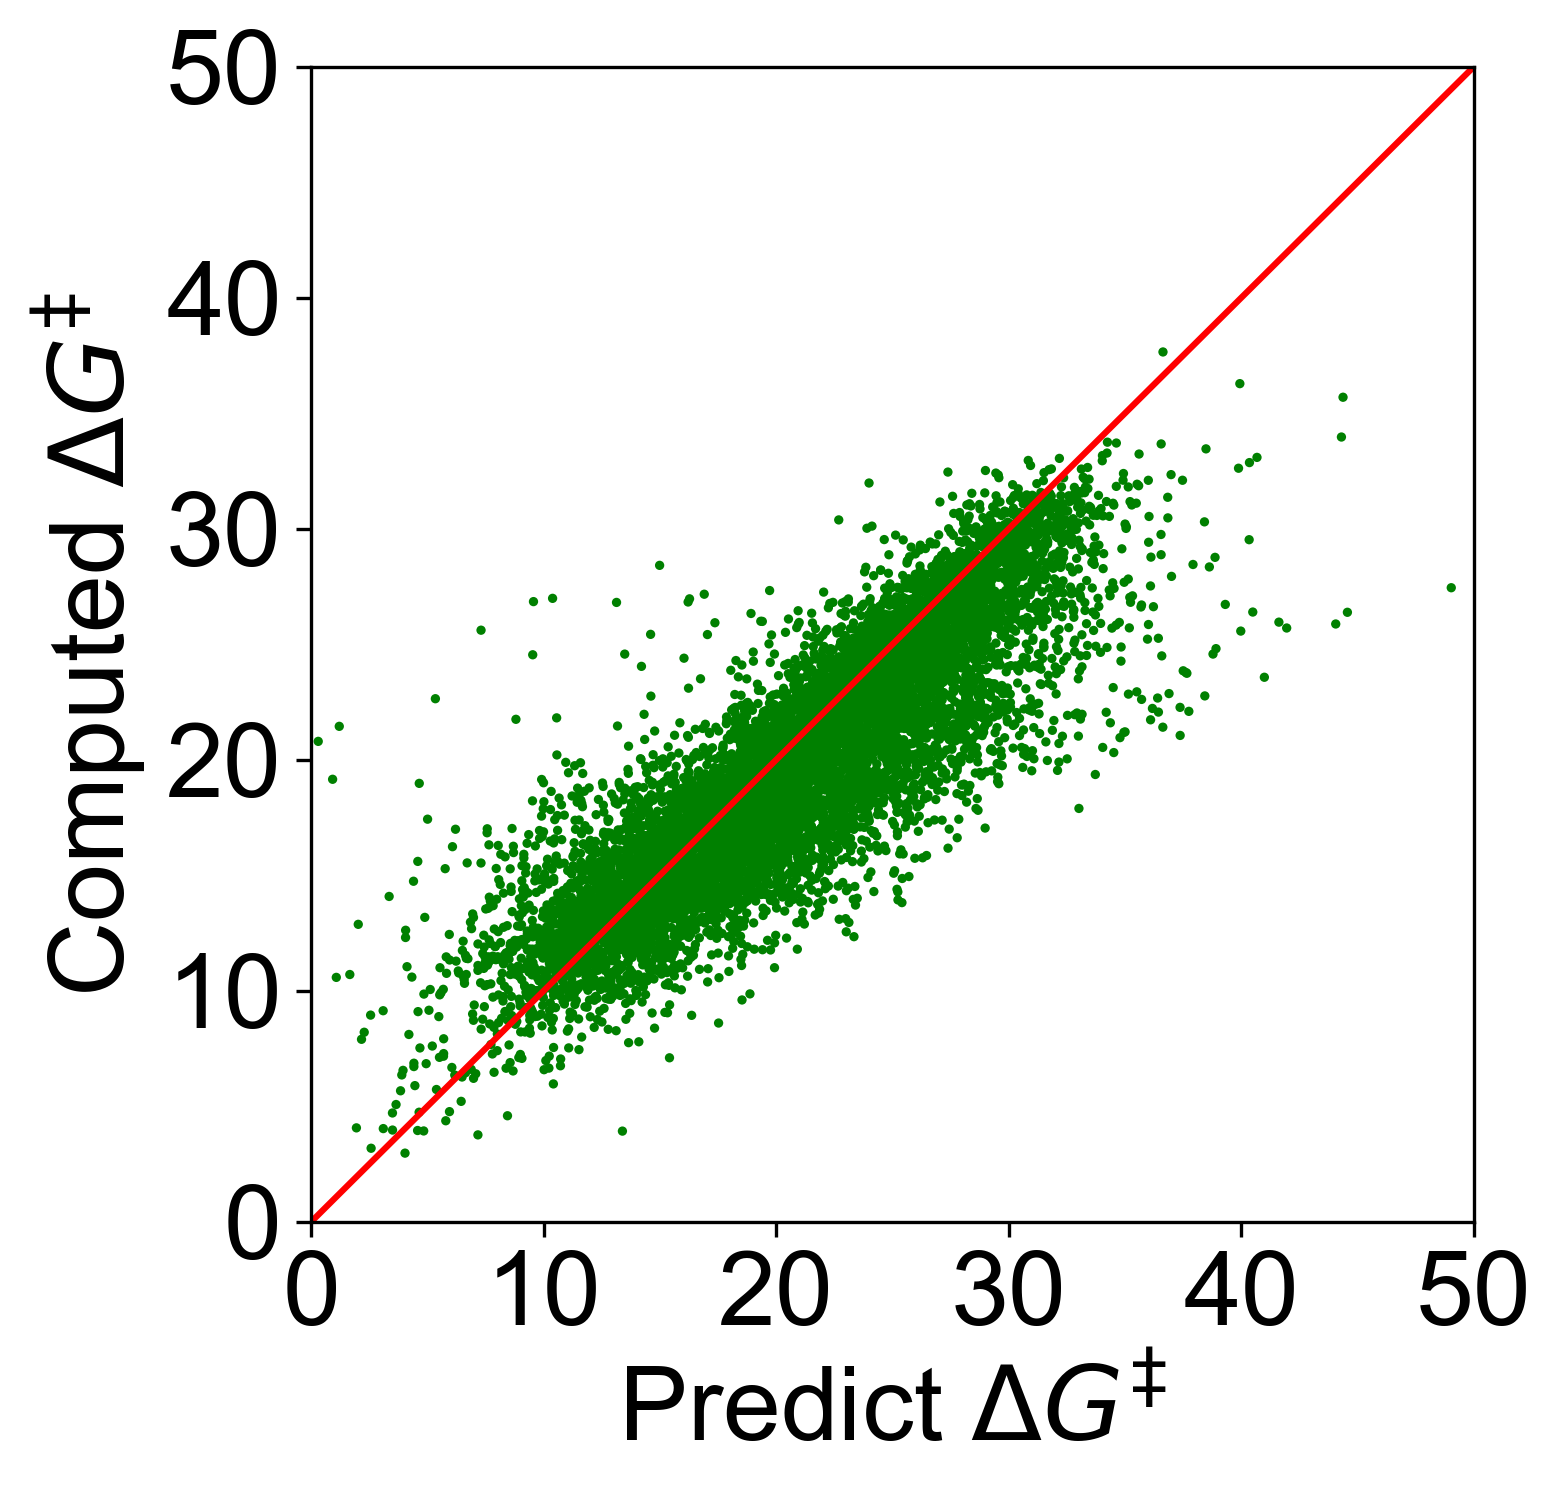

,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,B_type,R2BH,6737,2500,0.808557,2.041933,8.119509
1,B_type,RBH2,3303,5934,0.854490,1.755245,5.614904
2,B_type,BH3,8434,803,0.936600,1.120740,2.367567
3,Nu_type,Amine/Aryl N,3340,5897,0.755915,2.410668,10.410664
4,Nu_type,Phosphine,7404,1833,0.503666,2.385533,12.782575
5,Nu_type,NHC,7730,1507,0.750277,2.020231,7.422034
6,Cl_type,CCl4,9025,212,0.894737,1.378639,2.843366
7,Cl_type,CCl3,7444,1793,0.903820,1.412401,3.526066
8,Cl_type,CCl2,7130,2107,0.894317,1.485385,4.010414
9,Cl_type,CCl,4112,5125,0.576747,3.267642,18.148714


In [20]:
def add_ood_type_columns(df):
    typed_df = df.copy()
    typed_df["B_type"] = typed_df["B_smiles"].map(get_boron_type)
    typed_df["Nu_type"] = typed_df["N_Index"].map(get_lb_type)
    typed_df["Cl_type"] = typed_df["Cl_smiles"].map(get_cl_substrate_type)
    return typed_df


def run_type_ood(
    typed_df,
    type_column,
    type_order=None,
    target_column="deltaGa(kcal/mol)",
    min_test_size=2,
):
    if type_order is None:
        type_order = sorted(typed_df[type_column].dropna().unique())

    result_rows = []
    pred_rows = []
    for heldout_type in type_order:
        test_df = typed_df.loc[typed_df[type_column] == heldout_type].reset_index(drop=True)
        train_df = typed_df.loc[typed_df[type_column] != heldout_type].reset_index(drop=True)
        if len(test_df) < min_test_size or len(train_df) == 0:
            continue

        train_X = dataframe_to_descriptors(
            train_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        test_X = dataframe_to_descriptors(
            test_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        train_y = train_df[target_column]
        test_y = test_df[target_column]

        model = CatBoostRegressor(
            iterations=10000,
            learning_rate=0.01,
            depth=6,
            verbose=0,
            random_state=0,
        )
        model.fit(train_X, train_y)
        y_pred = model.predict(test_X)

        result_rows.append({
            "OOD_axis": type_column,
            "heldout_type": heldout_type,
            "train_size": len(train_df),
            "test_size": len(test_df),
            "R2": r2_score(test_y, y_pred),
            "MAE": mean_absolute_error(test_y, y_pred),
            "MSE": mean_squared_error(test_y, y_pred),
        })
        pred_rows.extend(
            {
                "OOD_axis": type_column,
                "heldout_type": heldout_type,
                "y_true": y_true,
                "y_pred": pred,
            }
            for y_true, pred in zip(test_y.to_numpy(), y_pred)
        )

    return pd.DataFrame(result_rows), pd.DataFrame(pred_rows)


data_csv_typed = add_ood_type_columns(data_csv)
ood_type_counts = {
    "B_type": data_csv_typed["B_type"].value_counts().reindex(B_TYPE_ORDER).dropna().astype(int),
    "Nu_type": data_csv_typed["Nu_type"].value_counts().reindex(LB_TYPE_ORDER).dropna().astype(int),
    "Cl_type": data_csv_typed["Cl_type"].value_counts().reindex(CL_SUBSTRATE_TYPE_ORDER).dropna().astype(int),
}
for axis_name, counts in ood_type_counts.items():
    print(f"{axis_name} counts:")
    print(counts.to_string())
    print()


ood_type_results = {}
ood_type_predictions = {}
ood_type_configs = {
    "B_type": B_TYPE_ORDER,
    "Nu_type": LB_TYPE_ORDER,
    "Cl_type": CL_SUBSTRATE_TYPE_ORDER,
}

for type_column, type_order in ood_type_configs.items():
    result_df, pred_df = run_type_ood(
        data_csv_typed,
        type_column=type_column,
        type_order=type_order,
    )
    ood_type_results[type_column] = result_df
    ood_type_predictions[type_column] = pred_df

    print(f"OOD by {type_column}")
    display(result_df)
    if pred_df.empty:
        print(f"No valid OOD folds for {type_column}")
        continue
    print(
        "Overall R2:",
        r2_score(pred_df["y_true"], pred_df["y_pred"]),
        "MAE:",
        mean_absolute_error(pred_df["y_true"], pred_df["y_pred"]),
    )
    plot_scatter_with_metrics(
        pred_df["y_true"].to_numpy(),
        pred_df["y_pred"].to_numpy(),
        min_=0,
        max_=50,
    )


nonempty_ood_type_results = [
    result_df for result_df in ood_type_results.values() if not result_df.empty
]
if nonempty_ood_type_results:
    ood_type_summary = pd.concat(nonempty_ood_type_results, ignore_index=True)
else:
    ood_type_summary = pd.DataFrame()
display(ood_type_summary)
